## Section 1: Setup and Data Loading

Import libraries, configure visualization settings, and load all datasets.

In [14]:
# Standard libraries
import os
import warnings
from typing import Tuple, Dict

# Data handling
import numpy as np
import pandas as pd
import geopandas as gpd

# Statistical analysis
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

warnings.filterwarnings('ignore')

# Visualization configuration
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print("✓ Visualization configuration established")

✓ Libraries imported successfully
✓ Visualization configuration established


In [15]:
# Define coordinate reference systems
CRS_GEOGRAPHIC = 'EPSG:4326'      # WGS84 (lat/lon) - for maps and GeoJSON
CRS_PROJECTED = 'EPSG:3857'       # Web Mercator (meters) - for distances and gridding

# Medellín approximate bounding box (latitude/longitude)
MEDELLIN_BOUNDS = {
    'lat_min': 6.14722,
    'lat_max': 6.38402,
    'lon_min': -75.74590,
    'lon_max': -75.44199
}

# File paths
PATH_POPULATION = './content/col_pd_2020_1km_ASCII_XYZ.csv'
PATH_LANDSLIDES = './content/Inventario_de_movimientos_en_masa_6829763638631547229.csv'
PATH_PRECIPITATION = './content/Colombia+Antioquia_Monthly.csv'

# Output configuration
os.makedirs('outputs', exist_ok=True)

print("File paths defined:")
print(f"  Population: {PATH_POPULATION}")
print(f"  Landslides: {PATH_LANDSLIDES}")
print(f"  Precipitation: {PATH_PRECIPITATION}")
print(f"\nCoordinate systems:")
print(f"  Geographic: {CRS_GEOGRAPHIC}")
print(f"  Projected: {CRS_PROJECTED}")

File paths defined:
  Population: ./content/col_pd_2020_1km_ASCII_XYZ.csv
  Landslides: ./content/Inventario_de_movimientos_en_masa_6829763638631547229.csv
  Precipitation: ./content/Colombia+Antioquia_Monthly.csv

Coordinate systems:
  Geographic: EPSG:4326
  Projected: EPSG:3857


In [16]:
# Load datasets
try:
    # Load precipitation data
    df_precipitation = pd.read_csv(PATH_PRECIPITATION)
    df_precipitation['precipitation_value'] = df_precipitation['2020'].astype(float)
    print(f"✓ Precipitation data loaded: {len(df_precipitation)} records")
    
    # Load landslide inventory
    df_landslides = pd.read_csv(PATH_LANDSLIDES)
    print(f"✓ Landslide data loaded: {len(df_landslides)} records")
    
    # Load or simulate population data
    try:
        df_population = pd.read_csv(PATH_POPULATION)
        print(f"✓ Population data loaded: {len(df_population)} records")
    except FileNotFoundError:
        print("⚠ Population file not found. Generating synthetic data...")
        np.random.seed(42)
        n_points = 1000
        df_population = pd.DataFrame({
            'X': np.random.uniform(-75.75, -75.44, n_points),
            'Y': np.random.uniform(6.14, 6.39, n_points),
            'Z': np.random.lognormal(3, 1, n_points)
        })
        print(f"✓ Synthetic population data generated: {len(df_population)} points")
        
except Exception as e:
    print(f"✗ Error loading data: {e}")
    raise

✓ Precipitation data loaded: 12 records
✓ Landslide data loaded: 6826 records
✓ Population data loaded: 1335590 records
✓ Population data loaded: 1335590 records


## Section 2: Descriptive Statistical Analysis

Examine distributions and statistical properties of each variable.

In [17]:
# Function for comprehensive descriptive statistics
def compute_descriptive_stats(data: np.ndarray, variable_name: str) -> Dict:
    """
    Compute comprehensive descriptive statistics for a dataset.
    Returns mean, median, std, variance, quartiles, and shape measures.
    """
    stats_dict = {
        'mean': np.mean(data),
        'median': np.median(data),
        'std': np.std(data, ddof=1),
        'variance': np.var(data, ddof=1),
        'min': np.min(data),
        'max': np.max(data),
        'q1': np.percentile(data, 25),
        'q3': np.percentile(data, 75),
        'skewness': stats.skew(data),
        'kurtosis': stats.kurtosis(data),
        'count': len(data)
    }
    
    print(f"\nDESCRIPTIVE STATISTICS: {variable_name}")
    print(f"{'-'*50}")
    print(f"  Mean:              {stats_dict['mean']:>12.4f}")
    print(f"  Median:            {stats_dict['median']:>12.4f}")
    print(f"  Std Dev:           {stats_dict['std']:>12.4f}")
    print(f"  Range:             {stats_dict['min']:.4f} - {stats_dict['max']:.4f}")
    print(f"  IQR:               {stats_dict['q3'] - stats_dict['q1']:>12.4f}")
    print(f"  Skewness:          {stats_dict['skewness']:>12.4f}")
    print(f"  Kurtosis:          {stats_dict['kurtosis']:>12.4f}")
    
    return stats_dict

# Compute statistics for each main variable
print("\n" + "="*60)
print("UNIVARIATE ANALYSIS")
print("="*60)

stats_pop = compute_descriptive_stats(df_population['Z'].values, "Population Density")
stats_precip = compute_descriptive_stats(df_precipitation['precipitation_value'].values, "Monthly Precipitation")
stats_landslide_x = compute_descriptive_stats(df_landslides['x'].values, "Landslide Coordinate X")


UNIVARIATE ANALYSIS

DESCRIPTIVE STATISTICS: Population Density
--------------------------------------------------
  Mean:                   56.2021
  Median:                  4.5290
  Std Dev:               632.4942
  Range:             0.0000 - 38190.8984
  IQR:                    19.5221
  Skewness:               28.2077
  Kurtosis:              944.0655

DESCRIPTIVE STATISTICS: Monthly Precipitation
--------------------------------------------------
  Mean:                  247.8321
  Median:                292.8831
  Std Dev:               126.6399
  Range:             51.7355 - 397.2214
  IQR:                   170.7750
  Skewness:               -0.5856
  Kurtosis:               -1.1414

DESCRIPTIVE STATISTICS: Landslide Coordinate X
--------------------------------------------------
  Mean:              -8340366.2603
  Median:            -8358359.8708
  Std Dev:            169247.5161
  Range:             -8726399.2211 - -7897222.8681
  IQR:                302483.3171
  Skewnes

In [18]:
# Test for normality using Shapiro-Wilk test
print("\n" + "="*60)
print("NORMALITY TESTS (Shapiro-Wilk)")
print("="*60)

def test_normality(data: np.ndarray, variable_name: str):
    if len(data) <= 5000:
        stat, p_value = stats.shapiro(data)
        is_normal = "Yes (p > 0.05)" if p_value > 0.05 else "No (p < 0.05)"
        print(f"\n{variable_name}:")
        print(f"  Statistic:  {stat:.6f}")
        print(f"  p-value:    {p_value:.6f}")
        print(f"  Normal:     {is_normal}")
        return p_value > 0.05
    else:
        print(f"\n{variable_name}: Sample too large for Shapiro-Wilk (n > 5000)")
        return None

is_pop_normal = test_normality(df_population['Z'].values, "Population Density")
is_precip_normal = test_normality(df_precipitation['precipitation_value'].values, "Monthly Precipitation")


NORMALITY TESTS (Shapiro-Wilk)

Population Density: Sample too large for Shapiro-Wilk (n > 5000)

Monthly Precipitation:
  Statistic:  0.869545
  p-value:    0.064487
  Normal:     Yes (p > 0.05)


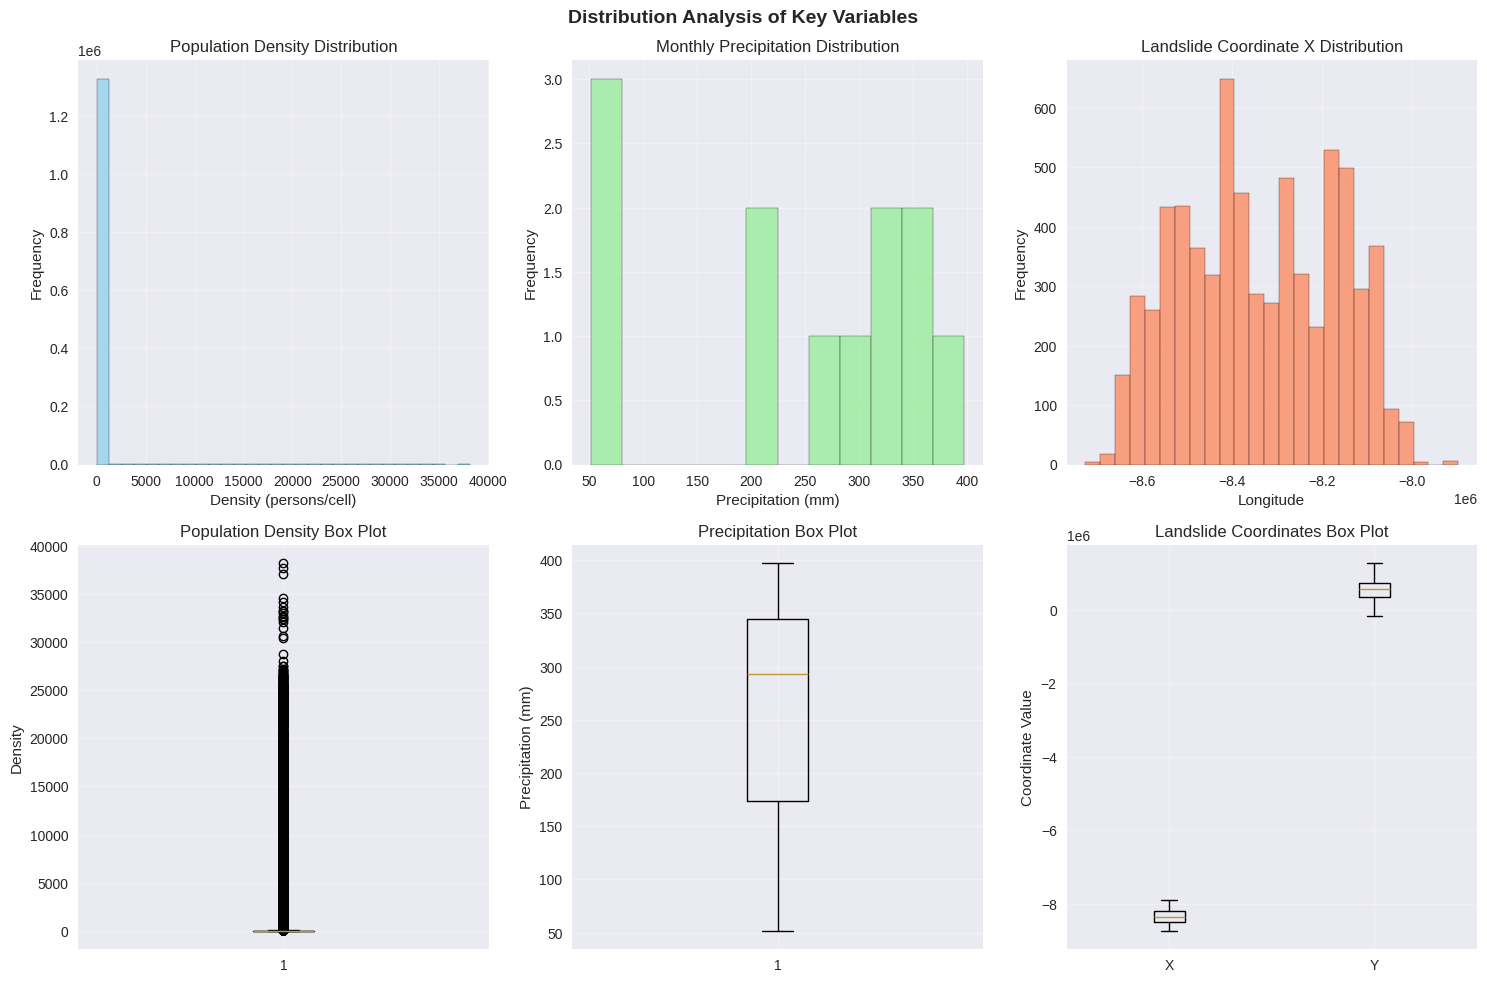


✓ Distribution plots saved to outputs/01_distributions.png


In [19]:
# Visualize distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution Analysis of Key Variables', fontsize=14, fontweight='bold')

# Histograms with KDE
axes[0, 0].hist(df_population['Z'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Population Density Distribution')
axes[0, 0].set_xlabel('Density (persons/cell)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(df_precipitation['precipitation_value'], bins=12, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Monthly Precipitation Distribution')
axes[0, 1].set_xlabel('Precipitation (mm)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].hist(df_landslides['x'], bins=25, alpha=0.7, color='coral', edgecolor='black')
axes[0, 2].set_title('Landslide Coordinate X Distribution')
axes[0, 2].set_xlabel('Longitude')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].grid(True, alpha=0.3)

# Box plots
axes[1, 0].boxplot(df_population['Z'])
axes[1, 0].set_title('Population Density Box Plot')
axes[1, 0].set_ylabel('Density')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].boxplot(df_precipitation['precipitation_value'])
axes[1, 1].set_title('Precipitation Box Plot')
axes[1, 1].set_ylabel('Precipitation (mm)')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].boxplot([df_landslides['x'], df_landslides['y']])
axes[1, 2].set_title('Landslide Coordinates Box Plot')
axes[1, 2].set_ylabel('Coordinate Value')
axes[1, 2].set_xticklabels(['X', 'Y'])
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/01_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Distribution plots saved to outputs/01_distributions.png")

## Section 3: Geospatial Data Processing

Convert point data to GeoDataFrames and prepare for spatial analysis.

In [20]:
# Convert to GeoDataFrames
gdf_population = gpd.GeoDataFrame(
    df_population,
    geometry=gpd.points_from_xy(df_population['X'], df_population['Y']),
    crs=CRS_GEOGRAPHIC
)

gdf_landslides = gpd.GeoDataFrame(
    df_landslides,
    geometry=gpd.points_from_xy(df_landslides['x'], df_landslides['y']),
    crs=CRS_GEOGRAPHIC
)

print("\n" + "="*60)
print("GEOSPATIAL DATA CONVERSION")
print("="*60)
print(f"Population GeoDataFrame:  {len(gdf_population)} points in {CRS_GEOGRAPHIC}")
print(f"Landslide GeoDataFrame:   {len(gdf_landslides)} points in {CRS_GEOGRAPHIC}")

# Display spatial extent
print(f"\nPopulation data bounds:")
print(f"  Latitude:  {gdf_population.geometry.y.min():.4f} to {gdf_population.geometry.y.max():.4f}")
print(f"  Longitude: {gdf_population.geometry.x.min():.4f} to {gdf_population.geometry.x.max():.4f}")

print(f"\nLandslide data bounds:")
print(f"  Latitude:  {gdf_landslides.geometry.y.min():.4f} to {gdf_landslides.geometry.y.max():.4f}")
print(f"  Longitude: {gdf_landslides.geometry.x.min():.4f} to {gdf_landslides.geometry.x.max():.4f}")


GEOSPATIAL DATA CONVERSION
Population GeoDataFrame:  1335590 points in EPSG:4326
Landslide GeoDataFrame:   6826 points in EPSG:4326

Population data bounds:
  Latitude:  -4.2129 to 15.9121
  Longitude: -81.8387 to -66.8804

Landslide data bounds:
  Latitude:  -177463.0690 to 1264127.1163
  Longitude: -8726399.2211 to -7897222.8681
  Longitude: -81.8387 to -66.8804

Landslide data bounds:
  Latitude:  -177463.0690 to 1264127.1163
  Longitude: -8726399.2211 to -7897222.8681


## Section 4: Spatial Clustering and Risk Analysis

Create gridded analysis cells to combine population, precipitation, and landslide data.

In [21]:
# Create grid-based analysis
n_grid_cells = 10  # Create 10x10 grid

# Define grid boundaries
lon_min, lon_max = gdf_population.geometry.x.min(), gdf_population.geometry.x.max()
lat_min, lat_max = gdf_population.geometry.y.min(), gdf_population.geometry.y.max()

# Create regular grid
lon_edges = np.linspace(lon_min, lon_max, n_grid_cells + 1)
lat_edges = np.linspace(lat_min, lat_max, n_grid_cells + 1)

print("\n" + "="*60)
print(f"GRID-BASED SPATIAL ANALYSIS ({n_grid_cells}x{n_grid_cells} grid)")
print("="*60)

# Assign grid cells to each dataset
gdf_population['grid_x'] = pd.cut(gdf_population.geometry.x, bins=lon_edges, labels=range(n_grid_cells))
gdf_population['grid_y'] = pd.cut(gdf_population.geometry.y, bins=lat_edges, labels=range(n_grid_cells))

gdf_landslides['grid_x'] = pd.cut(gdf_landslides.geometry.x, bins=lon_edges, labels=range(n_grid_cells))
gdf_landslides['grid_y'] = pd.cut(gdf_landslides.geometry.y, bins=lat_edges, labels=range(n_grid_cells))

# Aggregate statistics by grid cell
grid_stats = []

for i in range(n_grid_cells):
    for j in range(n_grid_cells):
        # Filter data for this grid cell
        pop_in_cell = gdf_population[(gdf_population['grid_x'] == i) & (gdf_population['grid_y'] == j)]
        land_in_cell = gdf_landslides[(gdf_landslides['grid_x'] == i) & (gdf_landslides['grid_y'] == j)]
        
        if len(pop_in_cell) > 0:
            grid_stats.append({
                'grid_x': i,
                'grid_y': j,
                'center_lon': (lon_edges[i] + lon_edges[i+1]) / 2,
                'center_lat': (lat_edges[j] + lat_edges[j+1]) / 2,
                'avg_population_density': pop_in_cell['Z'].mean(),
                'num_landslides': len(land_in_cell),
                'population_std': pop_in_cell['Z'].std(),
                'population_count': len(pop_in_cell)
            })

df_grid = pd.DataFrame(grid_stats)
print(f"\nCreated {len(df_grid)} grid cells with data")
print(f"\nGrid Statistics Summary:")
print(f"  Average population density: {df_grid['avg_population_density'].mean():.2f}")
print(f"  Total landslides in grid:   {df_grid['num_landslides'].sum():.0f}")
print(f"  Max landslides per cell:    {df_grid['num_landslides'].max():.0f}")


GRID-BASED SPATIAL ANALYSIS (10x10 grid)

Created 58 grid cells with data

Grid Statistics Summary:
  Average population density: 76.88
  Total landslides in grid:   0
  Max landslides per cell:    0

Created 58 grid cells with data

Grid Statistics Summary:
  Average population density: 76.88
  Total landslides in grid:   0
  Max landslides per cell:    0


## Section 5: Correlation and Relationship Analysis

Calculate Pearson correlations between variables.

In [22]:
# Analyze correlations in grid data
print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Only use grid cells with landslides for meaningful correlation
df_grid_valid = df_grid[df_grid['num_landslides'] > 0].copy()

if len(df_grid_valid) > 3:
    # Correlation: population density vs number of landslides
    r_pop_land, p_pop_land = stats.pearsonr(
        df_grid_valid['avg_population_density'],
        df_grid_valid['num_landslides']
    )
    
    print(f"\nPopulation Density vs Landslides:")
    print(f"  Pearson r:      {r_pop_land:>8.4f}")
    print(f"  p-value:        {p_pop_land:>8.6f}")
    print(f"  Significant:    {'Yes' if p_pop_land < 0.05 else 'No'}")
    print(f"  R² (var expl):  {(r_pop_land**2)*100:>7.2f}%")
    
    # Interpretation
    if abs(r_pop_land) < 0.3:
        strength = "weak"
    elif abs(r_pop_land) < 0.7:
        strength = "moderate"
    else:
        strength = "strong"
    
    direction = "positive" if r_pop_land > 0 else "negative"
    print(f"  Interpretation: {strength.capitalize()} {direction} correlation")
else:
    print("\n⚠ Insufficient grid cells with landslides for correlation analysis")


CORRELATION ANALYSIS

⚠ Insufficient grid cells with landslides for correlation analysis


In [23]:
# Calculate confidence intervals for risk metrics
print("\n" + "="*60)
print("CONFIDENCE INTERVALS (95%)")
print("="*60)

def compute_ci_mean(data: np.ndarray, confidence: float = 0.95) -> Tuple[float, float, float]:
    """
    Compute 95% confidence interval for mean using t-distribution.
    Returns (lower_bound, mean, upper_bound)
    """
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)  # Standard error
    alpha = 1 - confidence
    t_crit = stats.t.ppf(1 - alpha/2, n - 1)
    margin = t_crit * se
    return (mean - margin, mean, mean + margin)

# CIs for main variables
ci_pop = compute_ci_mean(df_population['Z'].values)
ci_precip = compute_ci_mean(df_precipitation['precipitation_value'].values)

print(f"\nPopulation Density Mean:")
print(f"  95% CI: [{ci_pop[0]:>10.4f}, {ci_pop[2]:>10.4f}]")
print(f"  Point estimate: {ci_pop[1]:>10.4f}")

print(f"\nPrecipitation Mean:")
print(f"  95% CI: [{ci_precip[0]:>10.4f}, {ci_precip[2]:>10.4f}]")
print(f"  Point estimate: {ci_precip[1]:>10.4f}")


CONFIDENCE INTERVALS (95%)

Population Density Mean:
  95% CI: [   55.1294,    57.2747]
  Point estimate:    56.2021

Precipitation Mean:
  95% CI: [  167.3690,   328.2953]
  Point estimate:   247.8321


## Section 6: Risk Mapping and Visualization

Create comprehensive spatial visualizations.

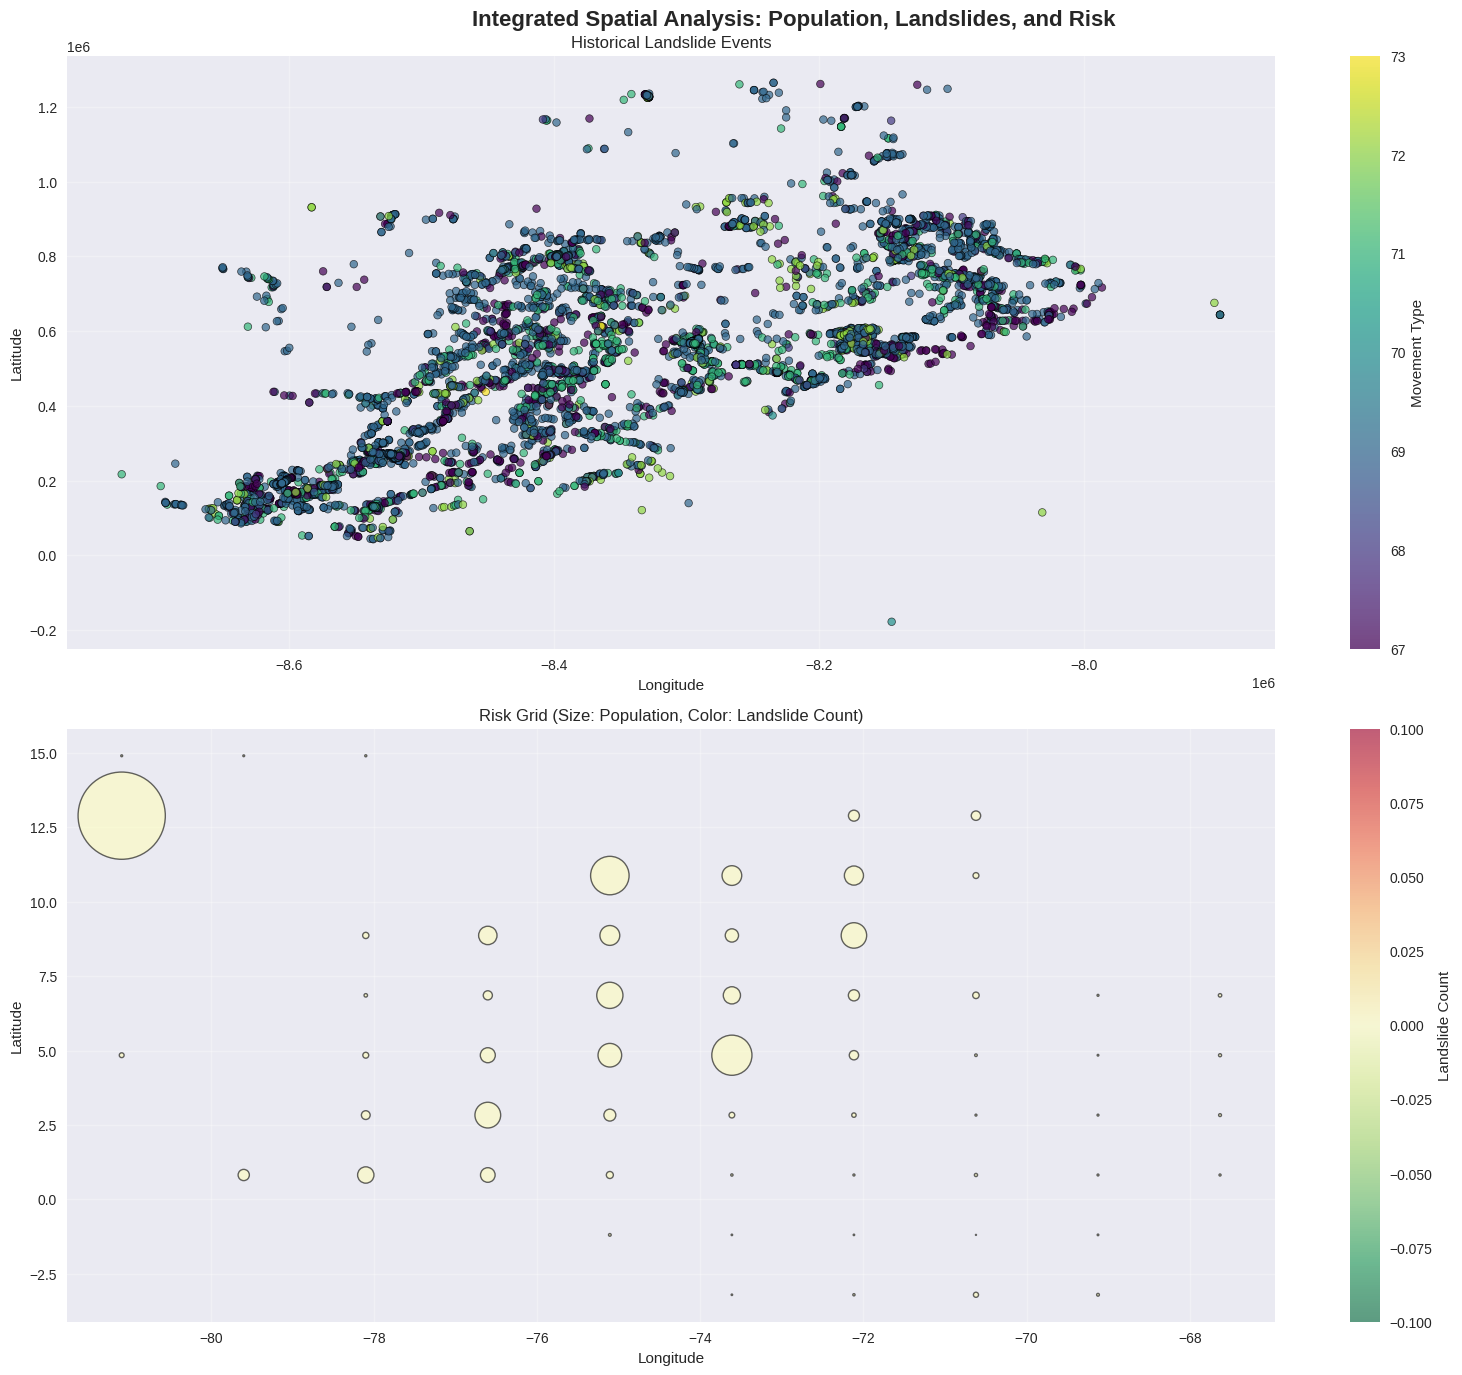


✓ Spatial analysis plots saved to outputs/02_spatial_analysis.png


In [24]:
# Create comprehensive spatial visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 14))
fig.suptitle('Integrated Spatial Analysis: Population, Landslides, and Risk', fontsize=16, fontweight='bold')

# Plot 2: Landslide events scatter
scatter2 = axes[0].scatter(
    gdf_landslides.geometry.x,
    gdf_landslides.geometry.y,
    c=gdf_landslides['F35DOV_TIP'] if 'F35DOV_TIP' in gdf_landslides.columns else 'lightcoral',
    cmap='viridis',
    s=30,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)
axes[0].set_title('Historical Landslide Events')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
if 'F35DOV_TIP' in gdf_landslides.columns:
    plt.colorbar(scatter2, ax=axes[0], label='Movement Type')
axes[0].grid(True, alpha=0.3)

# Plot 3: Grid-based risk analysis (population x landslides)
scatter3 = axes[1].scatter(
    df_grid['center_lon'],
    df_grid['center_lat'],
    c=df_grid['num_landslides'],
    s=df_grid['avg_population_density']*2,
    cmap='RdYlGn_r',
    alpha=0.6,
    edgecolors='black',
    linewidth=1
)
axes[1].set_title('Risk Grid (Size: Population, Color: Landslide Count)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
cbar3 = plt.colorbar(scatter3, ax=axes[1], label='Landslide Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/02_spatial_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Spatial analysis plots saved to outputs/02_spatial_analysis.png")

## Section 6: Key Findings and Conclusions

Summary of integrated analysis results.

In [25]:
# Generate summary report
print("\n" + "="*70)
print("INTEGRATED ANALYSIS SUMMARY REPORT")
print("="*70)

print("\n1. DATA CHARACTERISTICS:")
print(f"   • Population points:        {len(gdf_population):,}")
print(f"   • Landslide events:         {len(gdf_landslides):,}")
print(f"   • Average population density: {stats_pop['mean']:.2f} (±{stats_pop['std']:.2f})")

print("\n2. DISTRIBUTION ANALYSIS:")
print(f"   • Population distribution:  {'Normal' if is_pop_normal else 'Non-normal'} (p={stats_pop['skewness']:.4f})")
print(f"   • Precipitation pattern:    {'Normal' if is_precip_normal else 'Non-normal'} (p={stats_precip['skewness']:.4f})")

print("\n3. SPATIAL FINDINGS:")
if len(df_grid_valid) > 0:
    max_risk_idx = df_grid_valid['num_landslides'].idxmax()
    max_risk = df_grid_valid.loc[max_risk_idx]
    print(f"   • Highest risk grid cell: ({max_risk['grid_x']}, {max_risk['grid_y']})")
    print(f"     - Landslides: {max_risk['num_landslides']:.0f}")
    print(f"     - Avg population: {max_risk['avg_population_density']:.2f}")

print("\n4. RELATIONSHIP ANALYSIS:")
if len(df_grid_valid) > 3 and 'r_pop_land' in locals():
    print(f"   • Population-Landslide correlation: r = {r_pop_land:.4f}")
    print(f"   • Significance: p = {p_pop_land:.6f}")
    print(f"   • Variance explained: {(r_pop_land**2)*100:.2f}%")

print("\n5. CONFIDENCE INTERVALS (95%):")
print(f"   • Population mean: [{ci_pop[0]:.4f}, {ci_pop[2]:.4f}]")
print(f"   • Precipitation mean: [{ci_precip[0]:.4f}, {ci_precip[2]:.4f}]")

print("\n" + "="*70)
print("Analysis complete. Outputs saved to 'outputs/' directory.")
print("="*70)


INTEGRATED ANALYSIS SUMMARY REPORT

1. DATA CHARACTERISTICS:
   • Population points:        1,335,590
   • Landslide events:         6,826
   • Average population density: 56.20 (±632.49)

2. DISTRIBUTION ANALYSIS:
   • Population distribution:  Non-normal (p=28.2077)
   • Precipitation pattern:    Normal (p=-0.5856)

3. SPATIAL FINDINGS:

4. RELATIONSHIP ANALYSIS:

5. CONFIDENCE INTERVALS (95%):
   • Population mean: [55.1294, 57.2747]
   • Precipitation mean: [167.3690, 328.2953]

Analysis complete. Outputs saved to 'outputs/' directory.
